In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score







df = pd.read_csv('ufc_fights_ml.csv')
df



,fight_id,event_date,weight_class,outcome,fighter_a_name,fighter_b_name,fighter_a_age,fighter_a_height,fighter_a_reach,fighter_a_weight,...,fighter_b_takedown_defense,fighter_b_submission_attempts_per_fight,fighter_b_ko_tko_win_rate,fighter_b_control_time_per_fight,sig_strikes_landed_diff,sig_strike_accuracy_diff,takedowns_landed_diff,takedown_defense_diff,reach_diff,age_diff
0,00c6a2ef07ca51da,"December 14, 2024",Welterweight,0,Colby Covington,Joaquin Buckley,37.2,71.0,72.0,170,...,73,0.1,52.380952,5.306122,-0.41,1,1.86,-5,-4.0,6.2
1,7.52E+15,"December 14, 2024",Featherweight,1,Cub Swanson,Billy Quarantillo,41.5,68.0,70.0,145,...,61,1.0,33.333333,10.948276,-2.65,-3,-0.46,2,0.0,5.1
2,1a635a5e4551e7d5,"December 14, 2024",Flyweight,1,Manel Kape,Bruno Silva,31.5,65.0,68.0,125,...,60,0.2,28.571429,0.000000,1.50,6,-1.50,21,3.0,-3.7
3,7b1bc4ff776f12c1,"December 14, 2024",Light Heavyweight,0,Vitor Petrino,Dustin Jacoby,27.7,74.0,77.0,205,...,62,0.0,30.000000,1.456311,-2.50,-2,2.91,9,1.0,-9.4
4,5238f6470d0557fb,"December 14, 2024",Bantamweight,0,Adrian Yanez,Daniel Marcos,31.4,67.0,70.0,135,...,84,0.0,5.882353,13.533333,1.12,-12,-0.99,-3,1.0,-0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8026,2f523b757f7f33a2,"June 28, 2025",Featherweight,0,Hyder Amil,Jose Delgado,35.1,69.0,70.0,145,...,71,0.0,30.000000,4.615385,-0.29,8,-3.81,10,-4.0,7.9
8027,815ff62ca8e217be,"June 28, 2025",Women's Flyweight,0,Viviane Araujo,Tracy Cortez,38.6,64.0,68.0,125,...,62,0.3,0.000000,33.133333,0.05,-2,-0.47,13,3.0,7.0
8028,d7be78c400e7e0f9,"June 28, 2025",Lightweight,1,Terrance McKinney,Viacheslav Borshchev,30.8,70.0,73.0,155,...,42,0.1,37.500000,0.000000,0.56,2,3.59,35,4.0,-2.7
8029,9bff9fe298e63357,"June 28, 2025",Welterweight,0,Niko Price,Jacobe Smith,35.8,72.0,76.0,170,...,100,0.8,18.181818,37.679558,-1.08,-23,-6.44,-50,4.0,6.3


In [12]:
import numpy as np

def create_all_features(df):
    """
    Applies all feature engineering steps to the dataframe.
    This includes creating diff features and advanced metrics using vectorized operations.
    """
    # Define the base numerical stats list
    NUMERICAL_FIGHTER_STATS = [
        'age', 'height', 'reach', 'weight', 'total_fights', 'win_percentage',
        'recent_wins', 'win_streak', 'sig_strikes_landed_per_min',
        'sig_strikes_absorbed_per_min', 'sig_strike_accuracy', 'sig_strike_defense',
        'takedowns_landed_per_fight', 'takedown_attempts_per_fight',
        'takedown_defense', 'submission_attempts_per_fight',
        'ko_tko_win_rate', 'control_time_per_fight'
    ]


    # --- Create basic difference features ---
    for stat in NUMERICAL_FIGHTER_STATS:
        df[f'{stat}_diff'] = df[f'fighter_a_{stat}'] - df[f'fighter_b_{stat}']

    # --- Create advanced features ---
    df['fighter_a_sig_strike_defense_ratio'] = df['fighter_a_sig_strike_defense'] / 100
    df['fighter_b_sig_strike_defense_ratio'] = df['fighter_b_sig_strike_defense'] / 100
    df['fighter_a_takedown_defense_ratio'] = df['fighter_a_takedown_defense'] / 100
    df['fighter_b_takedown_defense_ratio'] = df['fighter_b_takedown_defense'] / 100

    df['net_strike_rate_diff'] = (
        df['fighter_a_sig_strikes_landed_per_min'].fillna(0) - df['fighter_a_sig_strikes_absorbed_per_min'].fillna(0)
    ) - (
        df['fighter_b_sig_strikes_landed_per_min'].fillna(0) - df['fighter_b_sig_strikes_absorbed_per_min'].fillna(0)
    )
    # CORRECTED: Use np.where for conditional logic to avoid the ValueError
    df['takedown_success_rate_a'] = np.where(
        df['fighter_a_takedown_attempts_per_fight'] > 0,  # The condition to check for each row
        df['fighter_a_takedowns_landed_per_fight'] / df['fighter_a_takedown_attempts_per_fight'], # Value if True
        0  # Value if False (avoids division by zero)
    )
    df['takedown_success_rate_b'] = np.where(
        df['fighter_b_takedown_attempts_per_fight'] > 0,
        df['fighter_b_takedowns_landed_per_fight'] / df['fighter_b_takedown_attempts_per_fight'],
        0
    )
    df['takedown_success_rate_diff'] = df['takedown_success_rate_a'] - df['takedown_success_rate_b']

    df['abs_reach_diff'] = np.abs(df['fighter_a_reach'] - df['fighter_b_reach'])
    df['abs_height_diff'] = np.abs(df['fighter_a_height'] - df['fighter_b_height'])

    df['strike_defense_efficiency_diff'] = (df['fighter_a_sig_strike_defense_ratio'] * df['fighter_b_sig_strikes_landed_per_min']) - \
                                         (df['fighter_b_sig_strike_defense_ratio'] * df['fighter_a_sig_strikes_landed_per_min'])
    df['takedown_defense_efficiency_diff'] = (df['fighter_a_takedown_defense_ratio'] * df['fighter_b_takedowns_landed_per_fight']) - \
                                           (df['fighter_b_takedown_defense_ratio'] * df['fighter_a_takedowns_landed_per_fight'])

    striker_score_a = df['fighter_a_sig_strikes_landed_per_min'] * (df['fighter_a_sig_strike_accuracy'] / 100)
    striker_score_b = df['fighter_b_sig_strikes_landed_per_min'] * (df['fighter_b_sig_strike_accuracy'] / 100)
    grappler_score_a = df['fighter_a_takedowns_landed_per_fight'] + df['fighter_a_submission_attempts_per_fight']
    grappler_score_b = df['fighter_b_takedowns_landed_per_fight'] + df['fighter_b_submission_attempts_per_fight']
    df['striker_grappler_diff'] = (striker_score_a - grappler_score_a) - (striker_score_b - grappler_score_b)

    # CORRECT: Use np.maximum to vectorize the division-by-zero check
    df['strike_efficiency_diff'] = (df['fighter_a_sig_strikes_landed_per_min'] / np.maximum(df['fighter_a_sig_strikes_absorbed_per_min'], 0.1)) - \
                                   (df['fighter_b_sig_strikes_landed_per_min'] / np.maximum(df['fighter_b_sig_strikes_absorbed_per_min'], 0.1))
    
    df['striker_vs_grappler_mismatch'] = (
        (df['fighter_a_sig_strikes_landed_per_min'] > df['fighter_a_takedowns_landed_per_fight']) &
        (df['fighter_b_takedowns_landed_per_fight'] > df['fighter_b_sig_strikes_landed_per_min'])
    ).astype(int)

    return df

In [13]:
df.isnull().sum()

fight_id                                     0
event_date                                   0
weight_class                                 0
outcome                                      0
fighter_a_name                               0
fighter_b_name                               0
fighter_a_age                                5
fighter_a_height                             1
fighter_a_reach                            124
fighter_a_weight                             0
fighter_a_total_fights                       0
fighter_a_win_percentage                     0
fighter_a_recent_wins                        0
fighter_a_win_streak                         0
fighter_a_sig_strikes_landed_per_min         0
fighter_a_sig_strikes_absorbed_per_min       0
fighter_a_sig_strike_accuracy                0
fighter_a_sig_strike_defense                 0
fighter_a_takedowns_landed_per_fight         0
fighter_a_takedown_attempts_per_fight        0
fighter_a_takedown_defense                   0
fighter_a_sub

In [14]:
df['event_date'] = pd.to_datetime(df['event_date'])

In [15]:
df_featured = create_all_features(df.copy()) 

In [16]:
model_features = [col for col in df_featured.columns if col.endswith('_diff')]
model_features.append('striker_vs_grappler_mismatch')
categorical_features = ['weight_class']
final_feature_list = model_features + categorical_features

In [17]:
X = df_featured[final_feature_list]
y = df_featured['outcome']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [19]:
from sklearn.impute import SimpleImputer


preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), model_features), # Impute numerical diff features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) # Encode weight class
    ],
    remainder='passthrough' # Keep other columns if any (safer)
)

In [20]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        # Static parameters
        objective='binary:logistic',
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,

        # Updated hyperparameters from your search
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        colsample_bytree=0.7,
        reg_alpha=0.0,
        reg_lambda=0.0,
        subsample=0.8
    ))
])


model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        # Static parameters
        objective='binary:logistic',
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,

        # Updated hyperparameters from your search
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=0.0,
        subsample=0.7
    ))
])








# model_pipeline = Pipeline(steps=[
#         ('preprocessor', preprocessor),
#         ('classifier', RandomForestClassifier(n_estimators=200, max_depth = 3, random_state=42, min_samples_split=5))
#     ])




In [21]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300, 400], # Number of trees
    'classifier__learning_rate': [0.01, 0.05, 0.1],   # Step size shrinkage
    'classifier__max_depth': [3, 4, 5, 6],          # Maximum depth of each tree
    'classifier__subsample': [0.7, 0.8, 0.9],       # Subsample ratio of the training instance
    'classifier__colsample_bytree': [0.7, 0.8, 0.9], # Subsample ratio of columns when constructing each tree
    # If you want to tune reg_alpha or reg_lambda, add them here to param_grid
    'classifier__reg_alpha': [0.0, 0.1, 0.5],
    'classifier__reg_lambda': [0.0, 0.1, 0.5]
}



In [22]:
# from sklearn.model_selection import RandomizedSearchCV


# # # grid_search = GridSearchCV(
# # #     estimator=  model_pipeline,
# # #     param_grid = param_grid,
# # #     cv =5,
# # #     scoring='accuracy',
# # #     n_jobs = -1,
# # #     verbose = 2
# # # )

# # # grid_search.fit(X_train, y_train)


# search = RandomizedSearchCV(
#     estimator=model_pipeline,  # if using pipeline
#     param_distributions=param_grid,
#     n_iter=120,         # Try 50 combinations instead of 3888
#     cv=5,
#     n_jobs=-1,
#     verbose=2,
#     random_state=42
# )

# search.fit(X_train, y_train)



In [23]:
# print("Best estimators found: ", search.best_params_)
# print("Best cross-validation accuracy: {:.4f}".format(search.best_score_))
# MODEL = search.best_estimator_

# # --- Model Evaluation (on the hold-out test set) ---
# test_accuracy = MODEL.score(X_test, y_test)
# print(f"Accuracy on the hold-out test set: {test_accuracy:.4f}")

In [24]:
model_pipeline.fit(X_train, y_train)    

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:57:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['sig_strikes_landed_diff',
                                                   'sig_strike_accuracy_diff',
                                                   'takedowns_landed_diff',
                                                   'takedown_defense_diff',
                                                   'reach_diff', 'age_diff',
                                                   'height_diff', 'weight_diff',
                                                   'total_fights_diff',
                                                   'win_percentage_diff',
                                                   'recent_wins_diff',
                                                   'win_st...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [25]:
#Used to get actual generic accuracy

cv_scores = cross_val_score(model_pipeline, X, y, cv=10)
print(f"***************** Cv accuracy: , {cv_scores.mean()} += {cv_scores.std()} ***************************"  )

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:57:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:57:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:57:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:57:17] WARNING: C:\actio

***************** Cv accuracy: , 0.7911837140573594 += 0.016536398229562706 ***************************


In [26]:
train_accuracy = model_pipeline.score(X_train, y_train)
test_accuracy = model_pipeline.score(X_test, y_test)
print(f"Training accuracy: {train_accuracy * 100}%")
print(f"Test accuracy: {test_accuracy * 100}%")





Training accuracy: 85.6631382316314%
Test accuracy: 79.27815805849409%


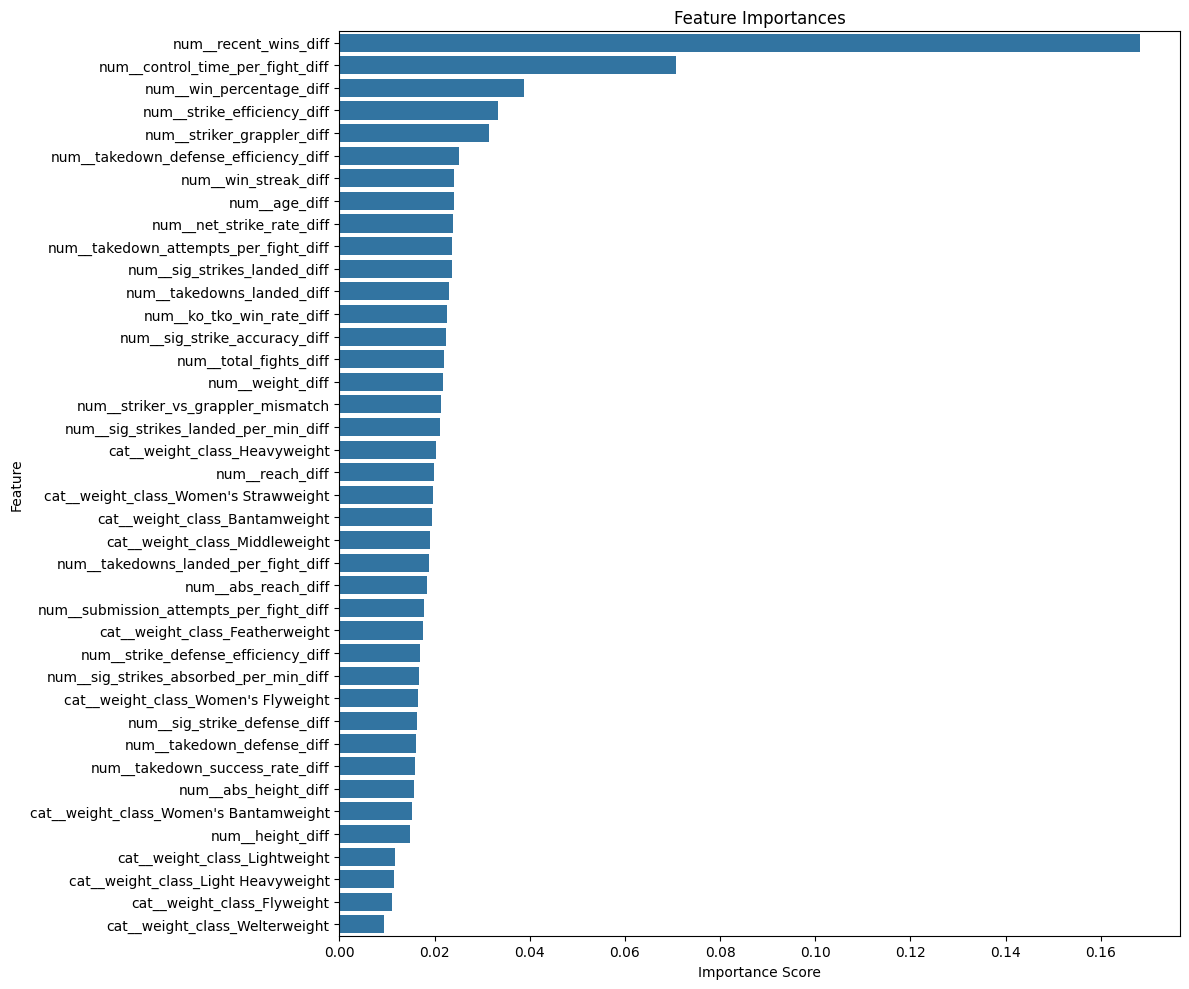

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. Re-create the list of feature names the model was trained on ---

# Define the base numerical stats list
NUMERICAL_FIGHTER_STATS = [
    'age', 'height', 'reach', 'weight', 'total_fights', 'win_percentage',
    'recent_wins', 'win_streak', 'sig_strikes_landed_per_min',
    'sig_strikes_absorbed_per_min', 'sig_strike_accuracy', 'sig_strike_defense',
    'takedowns_landed_per_fight', 'takedown_attempts_per_fight',
    'takedown_defense', 'submission_attempts_per_fight',
    'ko_tko_win_rate', 'control_time_per_fight'
]

# Create the list of basic difference features
all_diff_features = [f'{stat}_diff' for stat in NUMERICAL_FIGHTER_STATS]

# Add the names of the advanced features you created
all_diff_features.extend([
    'striker_grappler_diff',
    'strike_efficiency_diff',
    'striker_vs_grappler_mismatch',
    'net_strike_rate_diff',
    'takedown_success_rate_diff',
    'abs_reach_diff',
    'abs_height_diff',
    'strike_defense_efficiency_diff',
    'takedown_defense_efficiency_diff'
])


# --- 2. Your original plotting code (now with 'all_diff_features' defined) ---

# Get feature names from the ColumnTransformer
cat_features = model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out()

# Use the correctly defined list for numerical features
num_features = all_diff_features 

# Combine all final column names after preprocessing
all_feature_names =model_pipeline.named_steps['preprocessor'].get_feature_names_out()
# Get importances
importances = model_pipeline.named_steps['classifier'].feature_importances_

# Map names to values
feature_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(40)) # Show top 40
plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


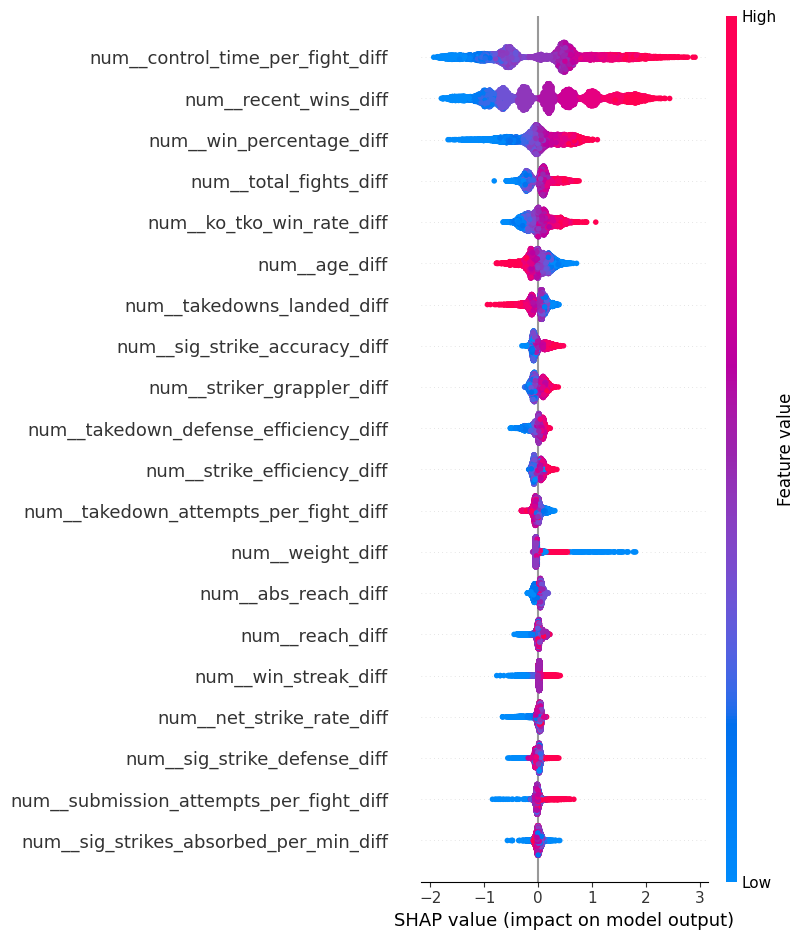

In [28]:
import shap
explainer = shap.TreeExplainer(model_pipeline.named_steps['classifier'])
X_transformed = model_pipeline.named_steps['preprocessor'].transform(X)
shap_values = explainer.shap_values(X_transformed)
shap.summary_plot(shap_values, features=X_transformed, feature_names = all_feature_names)




In [29]:
all_known_fighters = pd.concat([df['fighter_a_name'], df['fighter_b_name']])
all_known_fighters



0            Colby Covington
1                Cub Swanson
2                 Manel Kape
3              Vitor Petrino
4               Adrian Yanez
                ...         
8026            Jose Delgado
8027            Tracy Cortez
8028    Viacheslav Borshchev
8029            Jacobe Smith
8030             Alvin Hines
Length: 16062, dtype: object

In [30]:
from thefuzz import fuzz 
from thefuzz import process

def find_closest_fighter_name(input_name, all_fighter_names, threshold=80):
    for known_name in all_known_fighters:
        if input_name.lower() == known_name.lower():
            return known_name
    
    best_match, score, index = process.extractOne(input_name, all_known_fighters)
    
    if score >= threshold:
        if score < 100:
            confirmation = input(f"Did you mean {best_match}? Or someone else. (y/n)").lower()
            if confirmation == 'y':
                return best_match
            else:
                print("Correction rejected. Please re-enter the fighter's name")
                return None
        else:
            return best_match
    else:
        print(f"Could not find a Close  match for your fighter in our dataset. Best match found is {best_match}, Please check spelling.")
        return None

 





                          




    

In [31]:
def get_fighter_stats(fighter_name, full_df_imputed, imputer_fitted_obj, numerical_stats_list, raw_col_names_for_imputer):
    fighter_data_a = full_df_imputed[full_df_imputed['fighter_a_name'] == fighter_name].sort_values(by='event_date', ascending=False)
    fighter_data_b = full_df_imputed[full_df_imputed['fighter_b_name'] == fighter_name].sort_values(by='event_date', ascending=False)
    
    recent_fight = None
    prefix = '' # Initialize prefix to avoid UnboundLocalError in some paths

    if not fighter_data_a.empty and not fighter_data_b.empty:
        if fighter_data_a.iloc[0]['event_date'] >= fighter_data_b.iloc[0]['event_date']:
            recent_fight = fighter_data_a.iloc[0]
            prefix = 'fighter_a_'
        else:
            recent_fight = fighter_data_b.iloc[0]
            prefix = 'fighter_b_'
    elif not fighter_data_a.empty:
        recent_fight = fighter_data_a.iloc[0]
        prefix = 'fighter_a_'
    elif not fighter_data_b.empty:
        recent_fight = fighter_data_b.iloc[0]
        prefix = 'fighter_b_'
    else:
        return None # Fighter not found

    stats = {}
    for stat in numerical_stats_list:
        full_col_name = prefix + stat
        # Check if the specific stat exists and is not NaN in the fighter's latest record
        if full_col_name in recent_fight.index and pd.notna(recent_fight[full_col_name]):
            stats[stat] = recent_fight[full_col_name]
        else:
            # Fallback: if the stat was truly missing for this fighter (e.g., they only had NaNs for it),
            # use the median value from the overall training data as learned by the imputer.
            try:
                col_index_in_imputer = raw_col_names_for_imputer.index(full_col_name)
                stats[stat] = imputer_fitted_obj.statistics_[col_index_in_imputer]
            except ValueError:
                # Should not happen if `raw_col_names_for_imputer` is correctly formed.
                # If it does, a stat isn't in the imputed list, which is an issue.
                print(f"Warning: Stat '{full_col_name}' not found in imputer's training columns. Defaulting to NaN.")
                stats[stat] = np.nan # Or raise an error
    stats['weight_class'] = recent_fight['weight_class']

    return stats




def predict_fight_winner(fighter1_name, fighter2_name, weight_class, model, full_df):
    """
    Predicts the winner of a hypothetical fight using the trained pipeline.
    """
    # Find the most recent stats for each fighter
    fighter1_stats = full_df[full_df['fighter_a_name'] == fighter1_name].sort_values('event_date', ascending=False).iloc[0:1]
    if fighter1_stats.empty:
        fighter1_stats = full_df[full_df['fighter_b_name'] == fighter1_name].sort_values('event_date', ascending=False).iloc[0:1]

    fighter2_stats = full_df[full_df['fighter_a_name'] == fighter2_name].sort_values('event_date', ascending=False).iloc[0:1]
    if fighter2_stats.empty:
        fighter2_stats = full_df[full_df['fighter_b_name'] == fighter2_name].sort_values('event_date', ascending=False).iloc[0:1]

    if fighter1_stats.empty or fighter2_stats.empty:
        return "One or both fighters not found."

    # --- Create a single row DataFrame for prediction ---
    # We rename columns to the fighter_a/fighter_b format expected by our function
    f1_data = fighter1_stats.rename(columns=lambda c: c.replace('_a_', '_TEMP_').replace('_b_', '_a_').replace('_TEMP_', '_a_'))
    f2_data = fighter2_stats.rename(columns=lambda c: c.replace('_b_', '_TEMP_').replace('_a_', '_b_').replace('_TEMP_', '_b_'))

    # Combine the stats into one row
    prediction_df_raw = pd.DataFrame(columns=full_df.columns)
    prediction_data = {}
    for col in f1_data.columns:
        if col.startswith('fighter_a_'):
            prediction_data[col] = f1_data[col].values[0]
    for col in f2_data.columns:
        if col.startswith('fighter_b_'):
            prediction_data[col] = f2_data[col].values[0]
    
    prediction_data['weight_class'] = weight_class
    prediction_df_raw = pd.DataFrame([prediction_data])

    # --- Use the SAME feature engineering function ---
    predict_df_featured = create_all_features(prediction_df_raw)

    # --- Predict using the PIPELINE ---
    # The pipeline handles imputation and encoding automatically!
    prediction = model.predict(predict_df_featured)[0]
    prediction_proba = model.predict_proba(predict_df_featured)[0]

    if prediction == 1:
        winner = fighter1_name
        confidence = prediction_proba[1]
    else:
        winner = fighter2_name
        confidence = prediction_proba[0]

    return f"Predicted Winner: {winner} with {confidence:.2%} confidence."



# --- User Interaction ---
print("\n--- UFC Fight Predictor (Comprehensive) ---")
print("Enter fighter names and the weight class for the hypothetical fight.")
print("Names must match those in the dataset exactly (e.g., 'Dustin Jacoby', 'Adrian Yanez').")
print("Common weight classes: Light Heavyweight, Bantamweight, Lightweight, Featherweight, Women's Flyweight, Women's Strawweight, Flyweight, Welterweight, Heavyweight, Middleweight, Catch Weight.")


test_cases = [
    ("Ilia Topuria", "Arman Tsarukyan", "Lightweight"),
    ("Ilia Topuria", "Islam Makhachev", "Lightweight"),
    ("Max Holloway", "Dustin Poirier", "Lightweight"),
    ("Jailton Almeida", "Tom Aspinall", "Heavyweight"),
    ("Paulo Costa", "Roman Kopylov", "Middleweight"),
    ("Kevin Holland", "Daniel Rodriguez", "Welterweight"),
    ("Dan Ige", "Patricio Freire", "Featherweight"),
    ("Michael Johnson", "Daniel Zellhuber", "Lightweight")
]

for i, (f1, f2, wc) in enumerate(test_cases):
    print(f"\n--- Test Case {i+1} ---")
    print(f"Simulating input: Fighter 1: '{f1}', Fighter 2: '{f2}', Weight Class: '{wc}'")

    fighter1_name_exact = find_closest_fighter_name(f1, all_known_fighters)
    if fighter1_name_exact is None:
        print(f"Skipping prediciton because of unresolved fighter name for fighter name, {f1}")
        continue

    fighter2_name_exact = find_closest_fighter_name(f2, all_known_fighters)
    if fighter2_name_exact is None:
        print(f"Skipping prediciton because of unresolved fighter name for fighter name, {f1}")
        continue

    # Pass all necessary objects to the prediction function
    result = predict_fight_winner(f1, f2, wc, model_pipeline, df)

    print(result)

print("\n--- End of Simulated Predictions ---")
print("\nIf you were running this interactively, the prompt would continue now.")


--- UFC Fight Predictor (Comprehensive) ---
Enter fighter names and the weight class for the hypothetical fight.
Names must match those in the dataset exactly (e.g., 'Dustin Jacoby', 'Adrian Yanez').
Common weight classes: Light Heavyweight, Bantamweight, Lightweight, Featherweight, Women's Flyweight, Women's Strawweight, Flyweight, Welterweight, Heavyweight, Middleweight, Catch Weight.

--- Test Case 1 ---
Simulating input: Fighter 1: 'Ilia Topuria', Fighter 2: 'Arman Tsarukyan', Weight Class: 'Lightweight'


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()